In [ ]:
import pandas as pd

# We use the 'r' before the path to make sure Windows backslashes are read correctly
path = r'C:\Users\budid\OneDrive\Desktop\Coffee-Sales\venv\index.csv'

# Load the data
df = pd.read_csv(path)

# Success check
print("Data loaded successfully from the venv folder!")
print(f"Total rows found: {len(df)}")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'index.csv'

In [ ]:
# Fill missing card numbers with 'CASH'
df['card'] = df['card'].fillna('CASH')

# Check if there are any other missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
date           0
datetime       0
cash_type      0
card           0
money          0
coffee_name    0
dtype: int64


In [ ]:
# Convert to datetime objects
df['datetime'] = pd.to_datetime(df['datetime'])

# Extract useful features for analysis
df['hour'] = df['datetime'].dt.hour
df['day_name'] = df['datetime'].dt.day_name()

print("New columns 'hour' and 'day_name' created!")
print(df[['datetime', 'hour', 'day_name']].head())

New columns 'hour' and 'day_name' created!
                 datetime  hour day_name
0 2024-03-01 10:15:50.520    10   Friday
1 2024-03-01 12:19:22.539    12   Friday
2 2024-03-01 12:20:18.089    12   Friday
3 2024-03-01 13:46:33.006    13   Friday
4 2024-03-01 13:48:14.626    13   Friday


In [ ]:
from scipy import stats
import numpy as np

# Remove transactions where the price (money) is an extreme outlier
df_clean = df[(np.abs(stats.zscore(df['money'])) < 3)]

print(f"Rows before cleaning: {len(df)}")
print(f"Rows after cleaning: {len(df_clean)}")

Rows before cleaning: 1133
Rows after cleaning: 1133


C:\Users\budid\AppData\Local\Temp\ipykernel_24048\2588543844.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coffee_counts.values, y=coffee_counts.index, palette='viridis')


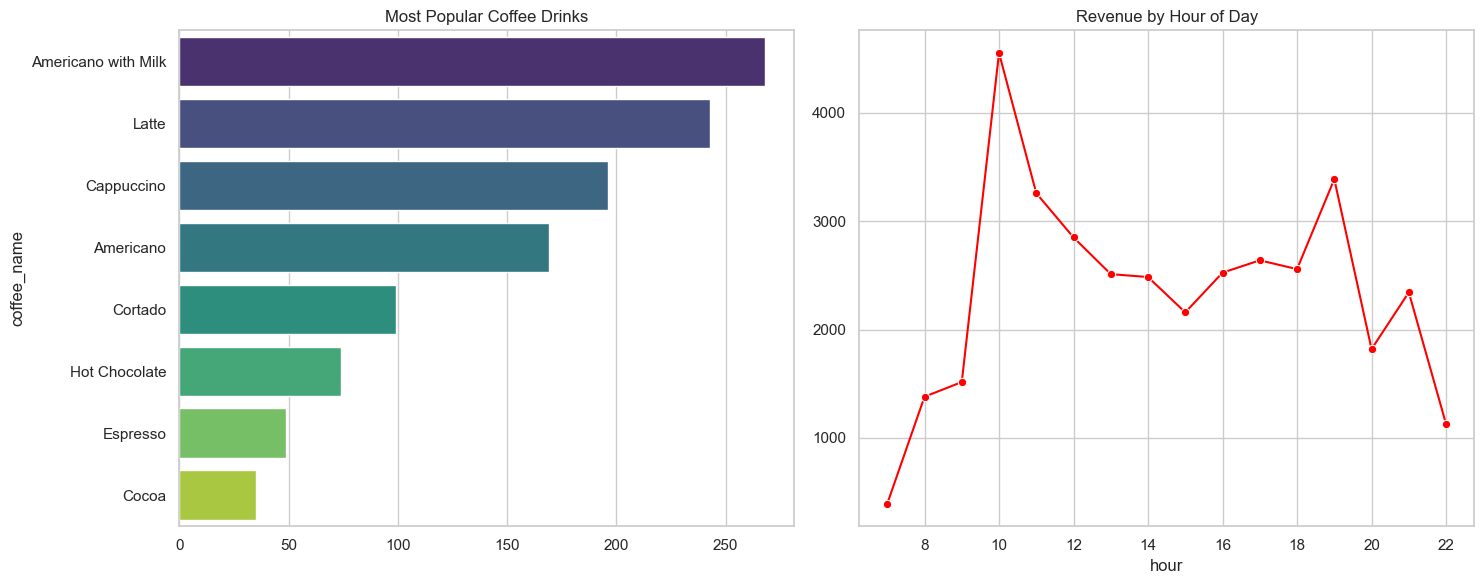

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# This is important for showing the graph inside VS Code
%matplotlib inline

# 1. Set the style
sns.set_theme(style="whitegrid")

# 2. Create the figure
plt.figure(figsize=(15, 6))

# 3. Chart 1: Best Sellers
plt.subplot(1, 2, 1)
coffee_counts = df_clean['coffee_name'].value_counts()
sns.barplot(x=coffee_counts.values, y=coffee_counts.index, palette='viridis')
plt.title('Most Popular Coffee Drinks')

# 4. Chart 2: Busy Hours
plt.subplot(1, 2, 2)
hourly_revenue = df_clean.groupby('hour')['money'].sum()
sns.lineplot(x=hourly_revenue.index, y=hourly_revenue.values, marker='o', color='red')
plt.title('Revenue by Hour of Day')

# 5. Show it!
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor

# 1. Encode text data into numbers (Machine Learning models only understand numbers)
le = LabelEncoder()
df_clean['coffee_encoded'] = le.fit_transform(df_clean['coffee_name'])
df_clean['cash_encoded'] = le.fit_transform(df_clean['cash_type'])

# 2. Select our Features (X) and what we want to predict (y)
X = df_clean[['hour', 'coffee_encoded', 'cash_encoded']]
y = df_clean['money']

# 3. Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data is ready for Machine Learning training!")

Data is ready for Machine Learning training!


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# 1. Initialize the Model (Random Forest is great for this kind of data)
model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Train the model using our training data
model.fit(X_train, y_train)

# 3. Make predictions on the test set
predictions = model.predict(X_test)

# 4. Check the accuracy (Lower error is better!)
error = mean_absolute_error(y_test, predictions)

print(f"Model Training Complete!")
print(f"Average Prediction Error: {error:.2f} currency units")

Model Training Complete!
Average Prediction Error: 1.38 currency units


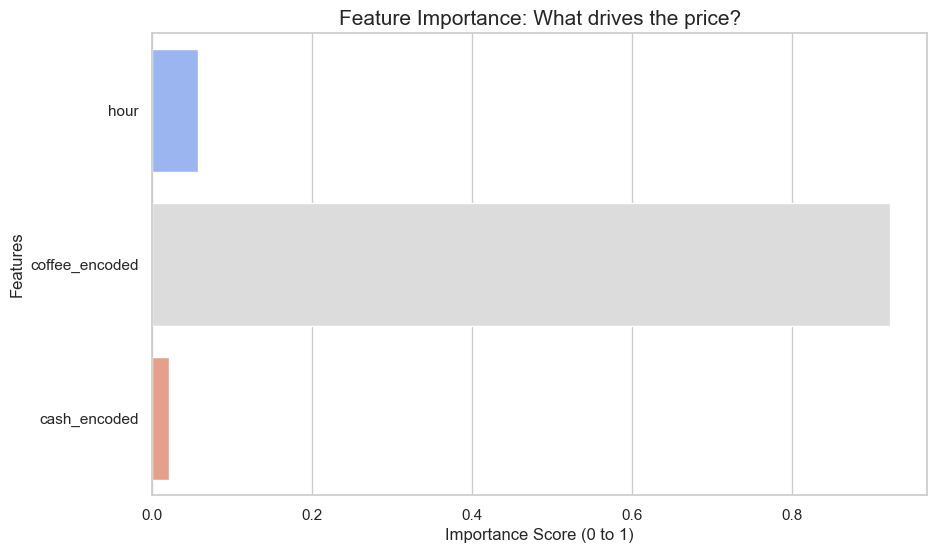

In [ ]:
# Get the importance of each feature
importances = model.feature_importances_
feature_names = X.columns

# Create the plot
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=feature_names, hue=feature_names, palette='coolwarm', legend=False)
plt.title('Feature Importance: What drives the price?', fontsize=15)
plt.xlabel('Importance Score (0 to 1)')
plt.ylabel('Features')
plt.show()

In [ ]:
# This shows which number corresponds to which coffee
menu = dict(zip(le.classes_, le.transform(le.classes_)))
print("Your Coffee Label Map:")
print(menu)

Your Coffee Label Map:
{'card': np.int64(0), 'cash': np.int64(1)}


In [ ]:
# Example: Hour=10, Coffee_encoded= (the number for Latte), Cash_encoded=0
# Change the '4' to whatever number your 'menu' showed for Latte
my_prediction = model.predict([[10, 4, 0]]) 

print(f"The AI predicts the price for this Latte sale will be: {my_prediction[0]:.2f}")

The AI predicts the price for this Latte sale will be: 27.68


c:\Users\budid\OneDrive\Desktop\Coffee-Sales\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [ ]:
import joblib

# Save the model to a file
joblib.dump(model, 'coffee_model.pkl')

# Save the label encoder so we remember which number belongs to which coffee
joblib.dump(le, 'coffee_encoder.pkl')

print("Success! Your AI 'brain' has been saved as coffee_model.pkl")

Success! Your AI 'brain' has been saved as coffee_model.pkl


In [ ]:
# Grouping by coffee name and summing the money
top_revenue = df_clean.groupby('coffee_name')['money'].sum().sort_values(ascending=False)

print("--- COFFEE BUSINESS SUMMARY ---")
print(f"Total Revenue: {df_clean['money'].sum():.2f}")
print(f"Busiest Hour: {df_clean['hour'].mode()[0]}:00")
print("\nTop 3 Revenue Drivers:")
print(top_revenue.head(3))

--- COFFEE BUSINESS SUMMARY ---
Total Revenue: 37508.88
Busiest Hour: 10:00

Top 3 Revenue Drivers:
coffee_name
Latte                  9009.14
Americano with Milk    8601.94
Cappuccino             7333.14
Name: money, dtype: float64


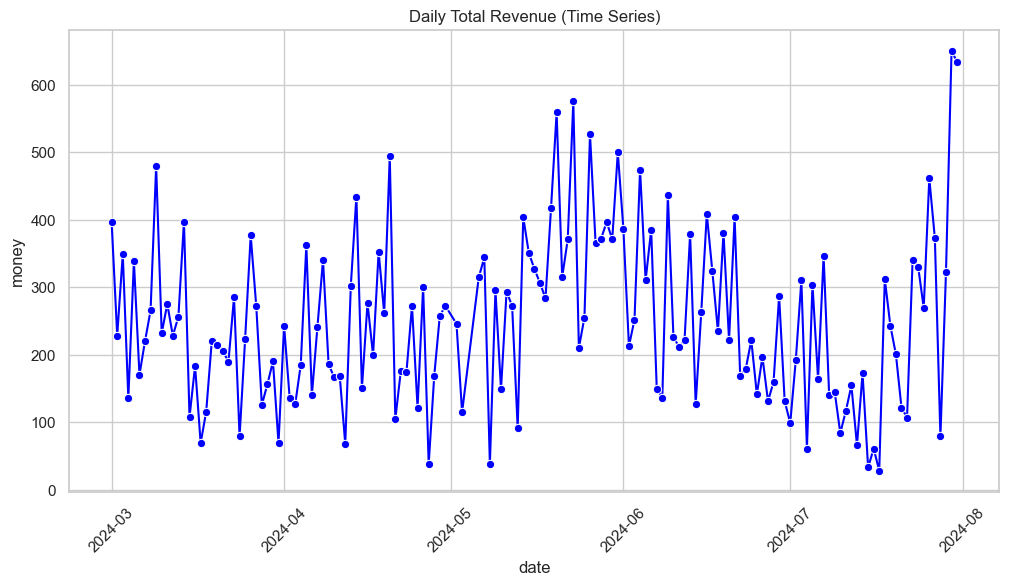

In [ ]:
# Grouping by date to see daily revenue trends
daily_sales = df_clean.groupby('date')['money'].sum().reset_index()
daily_sales['date'] = pd.to_datetime(daily_sales['date'])

plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_sales, x='date', y='money', marker='o', color='blue')
plt.title('Daily Total Revenue (Time Series)')
plt.xticks(rotation=45)
plt.show()

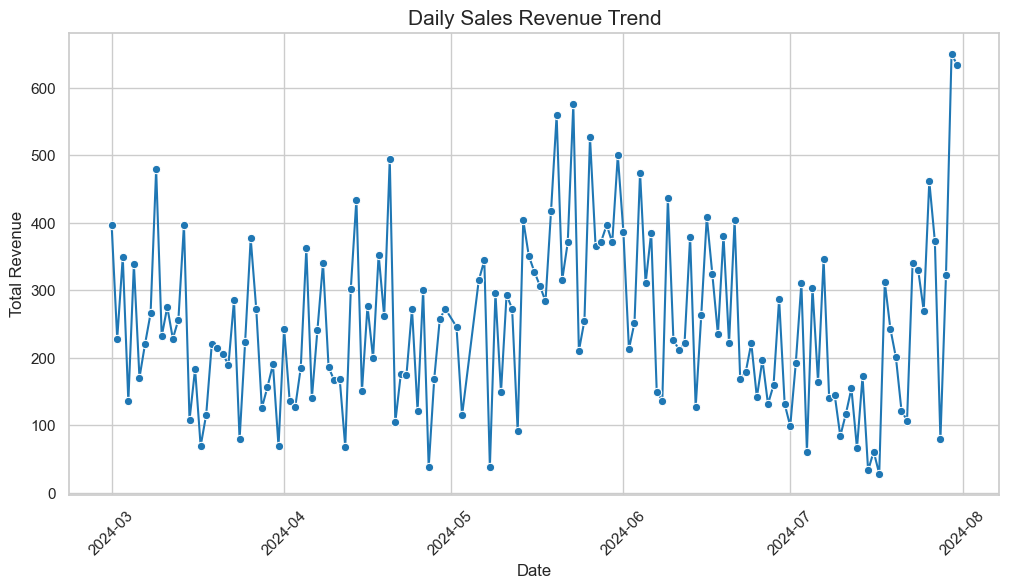

In [ ]:
# Convert 'date' to datetime objects for proper sorting
df_clean['date'] = pd.to_datetime(df_clean['date'])

# Group by date to get daily total revenue
daily_revenue = df_clean.groupby('date')['money'].sum().reset_index()

# Plotting the Time Series
plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_revenue, x='date', y='money', marker='o', color='tab:blue')
plt.title('Daily Sales Revenue Trend', fontsize=15)
plt.xlabel('Date')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Filter out 'CASH' since that doesn't track specific individuals
card_sales = df_clean[df_clean['card'] != 'CASH']

# Find the top 5 most frequent card users
loyal_customers = card_sales['card'].value_counts().head(5)

print("--- TOP 5 LOYAL CUSTOMERS (BY CARD) ---")
print(loyal_customers)

# Calculate how much the #1 customer spent
top_card = loyal_customers.index[0]
total_spent = card_sales[card_sales['card'] == top_card]['money'].sum()
print(f"\nYour top customer (Card {top_card}) has visited {loyal_customers.iloc[0]} times and spent {total_spent:.2f}!")

--- TOP 5 LOYAL CUSTOMERS (BY CARD) ---
card
ANON-0000-0000-0012    88
ANON-0000-0000-0009    63
ANON-0000-0000-0097    27
ANON-0000-0000-0003    23
ANON-0000-0000-0040    22
Name: count, dtype: int64

Your top customer (Card ANON-0000-0000-0012) has visited 88 times and spent 2593.18!


In [ ]:
# Calculate average daily revenue from our cleaned data
avg_daily_rev = daily_revenue['money'].mean()

print(f"--- SALES FORECAST ---")
print(f"Predicted Revenue for Tomorrow:  {avg_daily_rev:.2f}")
print(f"Predicted Revenue for Next Week: {avg_daily_rev * 7:.2f}")
print(f"Predicted Revenue for Next Month (30 days): {avg_daily_rev * 30:.2f}")

--- SALES FORECAST ---
Predicted Revenue for Tomorrow:  250.06
Predicted Revenue for Next Week: 1750.41
Predicted Revenue for Next Month (30 days): 7501.78


In [ ]:
# Save the final cleaned dataset with our new 'hour' and 'day_name' columns
df_clean.to_csv('coffee_sales_final_report.csv', index=False)

print("--- FINAL STEP COMPLETE ---")
print("Project ready for SQL upload. File saved as: coffee_sales_final_report.csv")

--- FINAL STEP COMPLETE ---
Project ready for SQL upload. File saved as: coffee_sales_final_report.csv


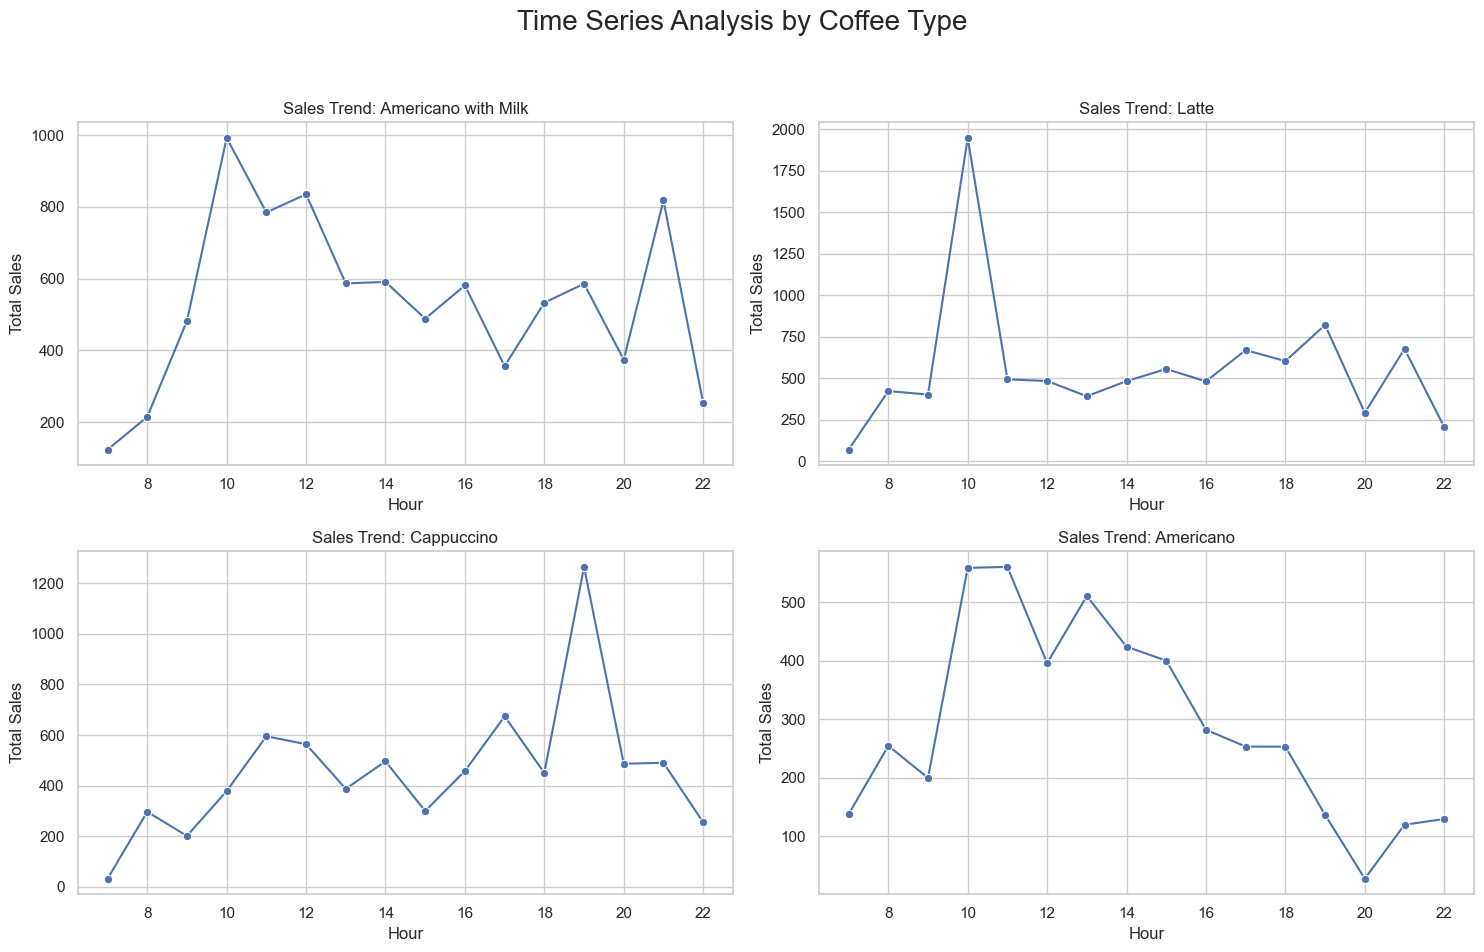

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with subplots for different coffee types
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
fig.suptitle('Time Series Analysis by Coffee Type', fontsize=20)

# Example: Plotting top 4 coffees over hours
top_coffees = df_clean['coffee_name'].value_counts().head(4).index
for i, coffee in enumerate(top_coffees):
    ax = axes[i//2, i%2]
    subset = df_clean[df_clean['coffee_name'] == coffee]
    sns.lineplot(data=subset.groupby('hour')['money'].sum(), ax=ax, marker='o')
    ax.set_title(f'Sales Trend: {coffee}')
    ax.set_xlabel('Hour')
    ax.set_ylabel('Total Sales')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

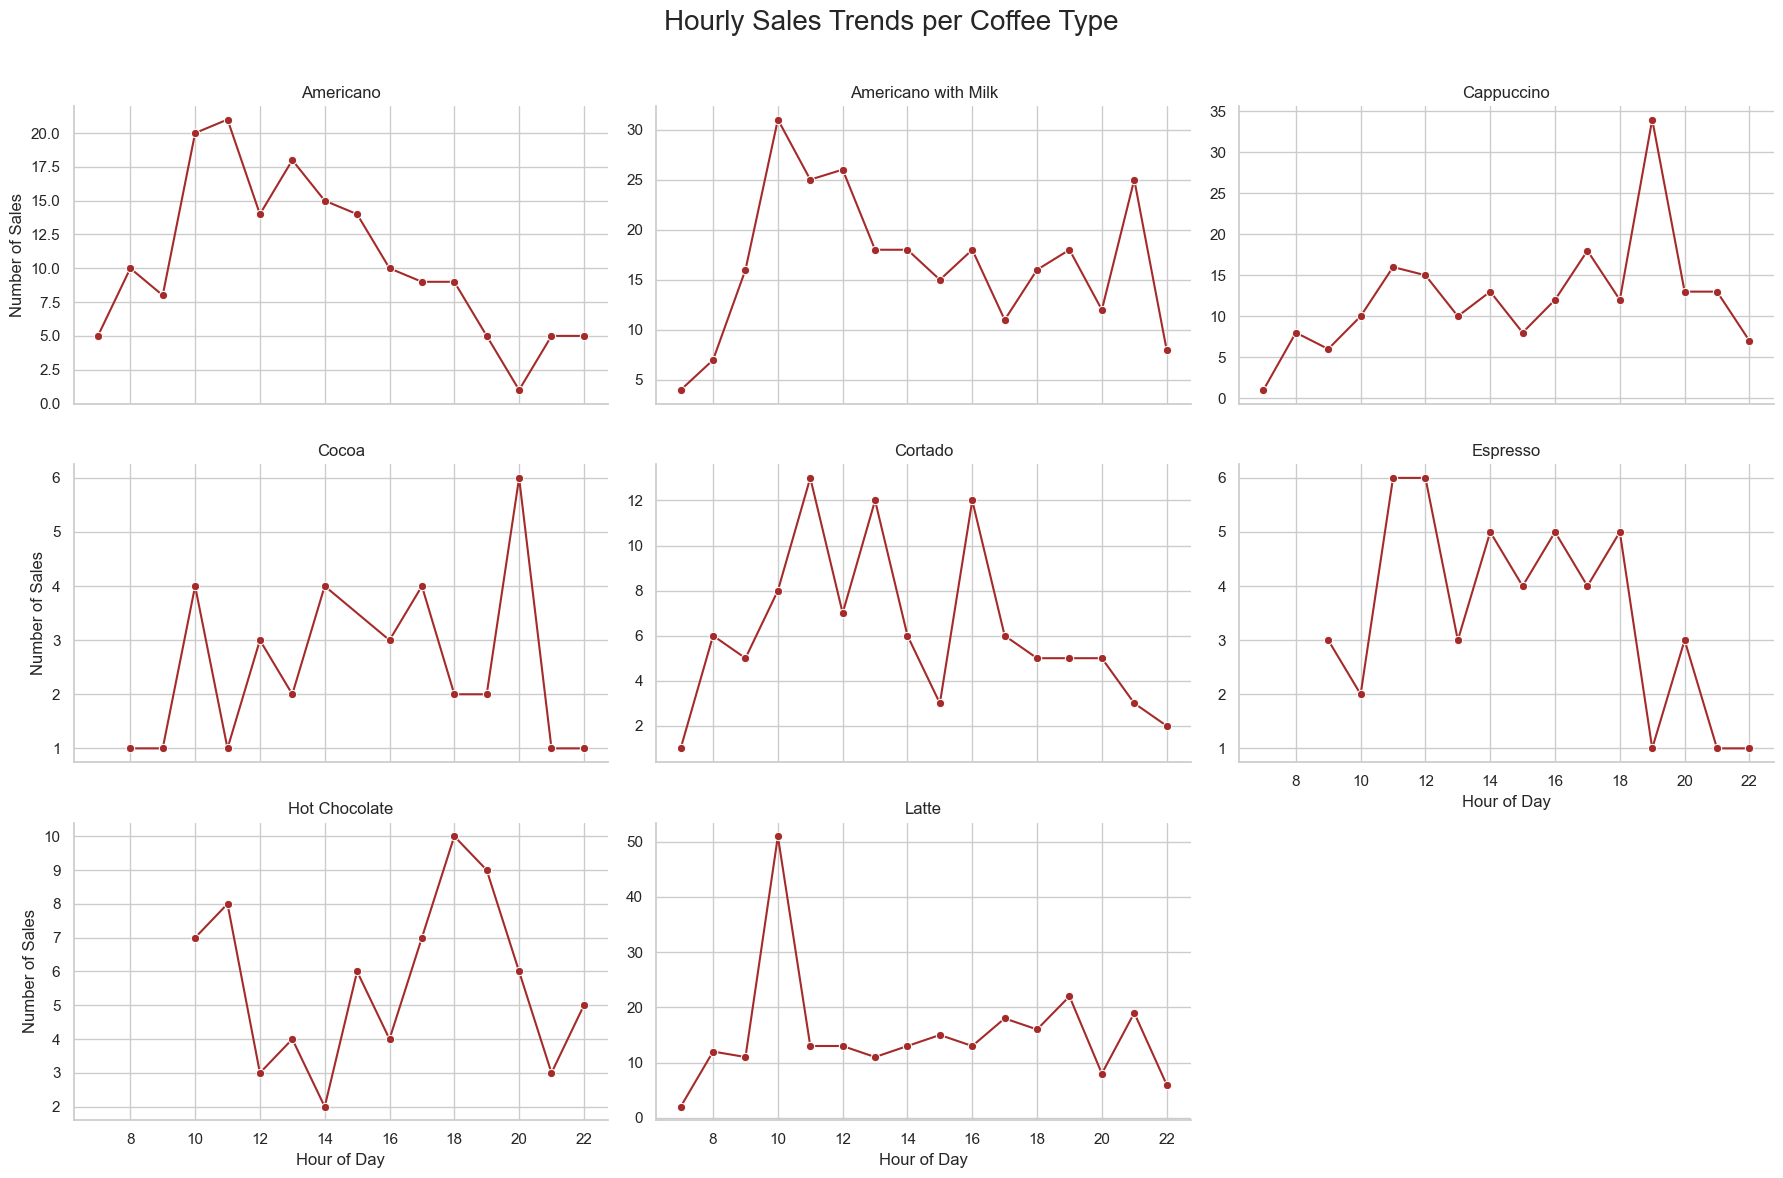

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare the data: Group by Coffee Name and Hour
grid_data = df_clean.groupby(['coffee_name', 'hour'])['money'].count().reset_index(name='sales_count')

# 2. Create the FacetGrid (This creates the "Grid" of charts)
# col_wrap=3 means it will put 3 charts per row
g = sns.FacetGrid(grid_data, col="coffee_name", col_wrap=3, height=4, aspect=1.5, sharey=False)

# 3. Map the lineplot to the grid
g.map(sns.lineplot, "hour", "sales_count", marker="o", color="brown")

# 4. Clean up the titles and labels
g.set_axis_labels("Hour of Day", "Number of Sales")
g.set_titles(col_template="{col_name}")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Hourly Sales Trends per Coffee Type', fontsize=20)

plt.show()

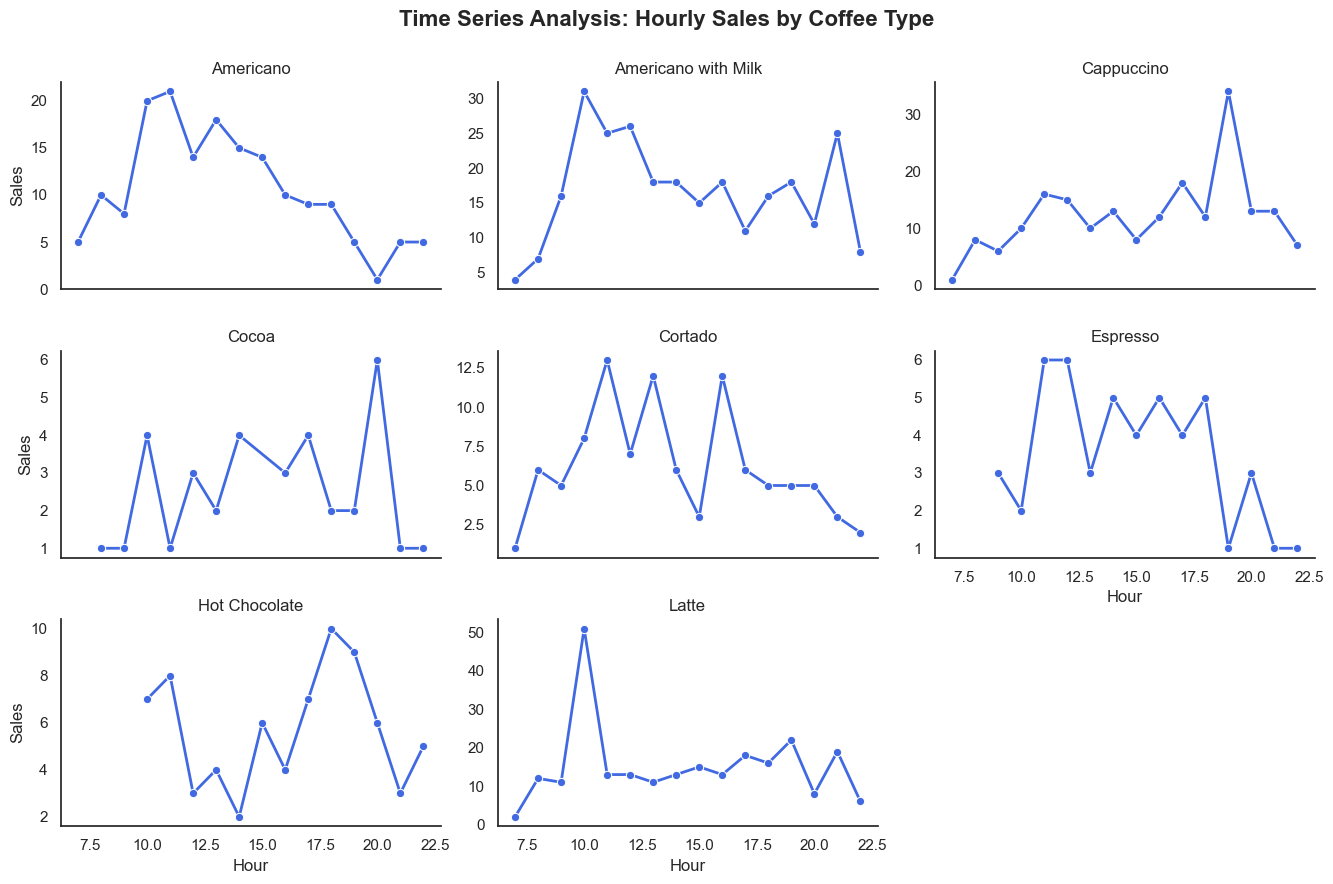

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare data: Group by coffee and hour, then count the number of sales
hourly_coffee_trends = df_clean.groupby(['coffee_name', 'hour']).size().reset_index(name='sales_count')

# 2. Set the style to match the clean white look in your PDF
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# 3. Create the Grid (FacetGrid)
# col_wrap=3 means 3 charts per row
g = sns.FacetGrid(hourly_coffee_trends, col="coffee_name", col_wrap=3, 
                  height=3, aspect=1.5, sharey=False)

# 4. Map the line plot to each grid square
g.map(sns.lineplot, "hour", "sales_count", marker="o", color="royalblue", linewidth=2)

# 5. Final formatting to match the "Professional" look
g.set_axis_labels("Hour", "Sales")
g.set_titles(col_template="{col_name}")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Time Series Analysis: Hourly Sales by Coffee Type', fontsize=16, fontweight='bold')

plt.show()

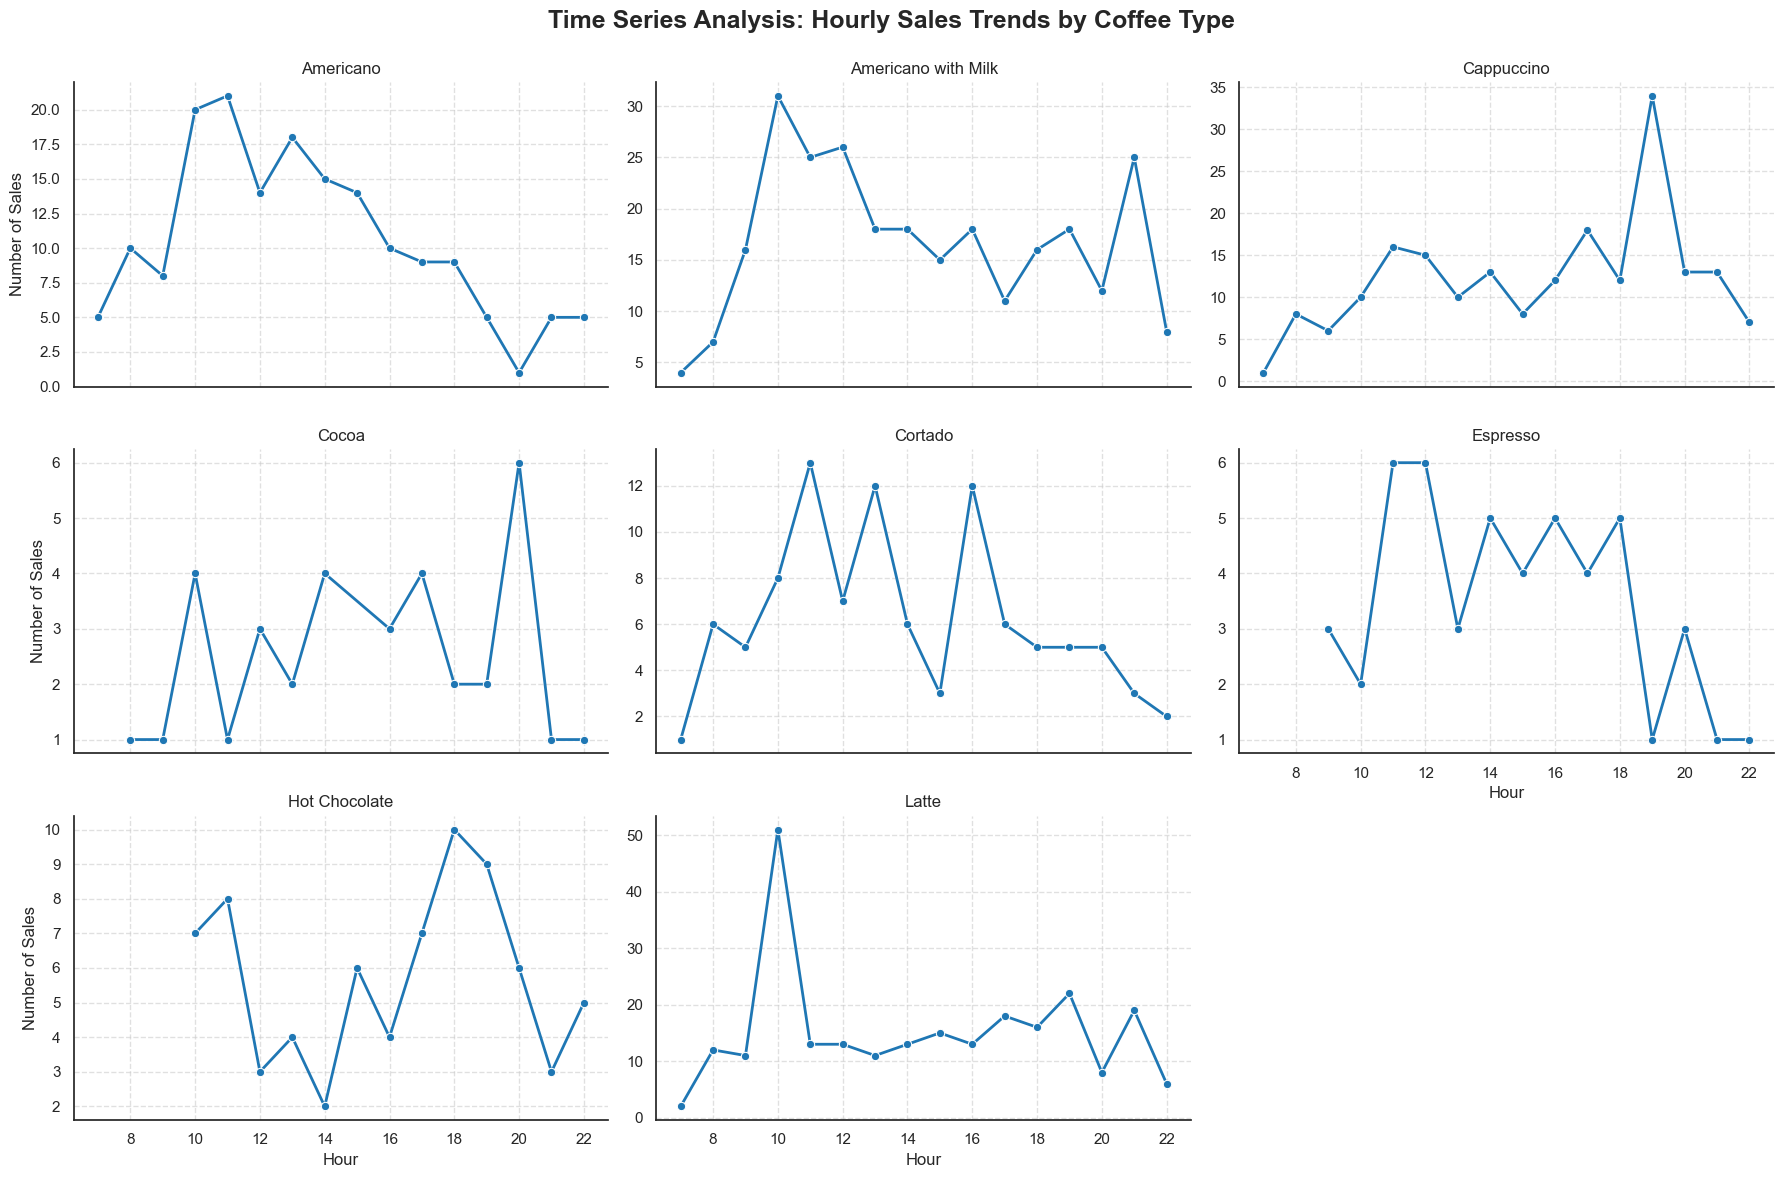

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare the data: Count sales per coffee per hour
grid_data = df_clean.groupby(['coffee_name', 'hour']).size().reset_index(name='sales_count')

# 2. Initialize the FacetGrid
# col_wrap=3 organizes them into 3 columns per row
g = sns.FacetGrid(grid_data, col="coffee_name", col_wrap=3, height=4, aspect=1.5, sharey=False)

# 3. Map the lineplot to the grid
# This creates the blue line with dots seen in your reference
g.map(sns.lineplot, "hour", "sales_count", marker="o", color="#1f77b4", linewidth=2)

# 4. Professional Formatting
g.set_axis_labels("Hour", "Number of Sales")
g.set_titles(col_template="{col_name}")
g.fig.subplots_adjust(top=0.92)
g.fig.suptitle('Time Series Analysis: Hourly Sales Trends by Coffee Type', fontsize=18, fontweight='bold')

# 5. Add a grid for that "Data Analyst" look
for ax in g.axes.flat:
    ax.grid(True, linestyle='--', alpha=0.6)

plt.show()

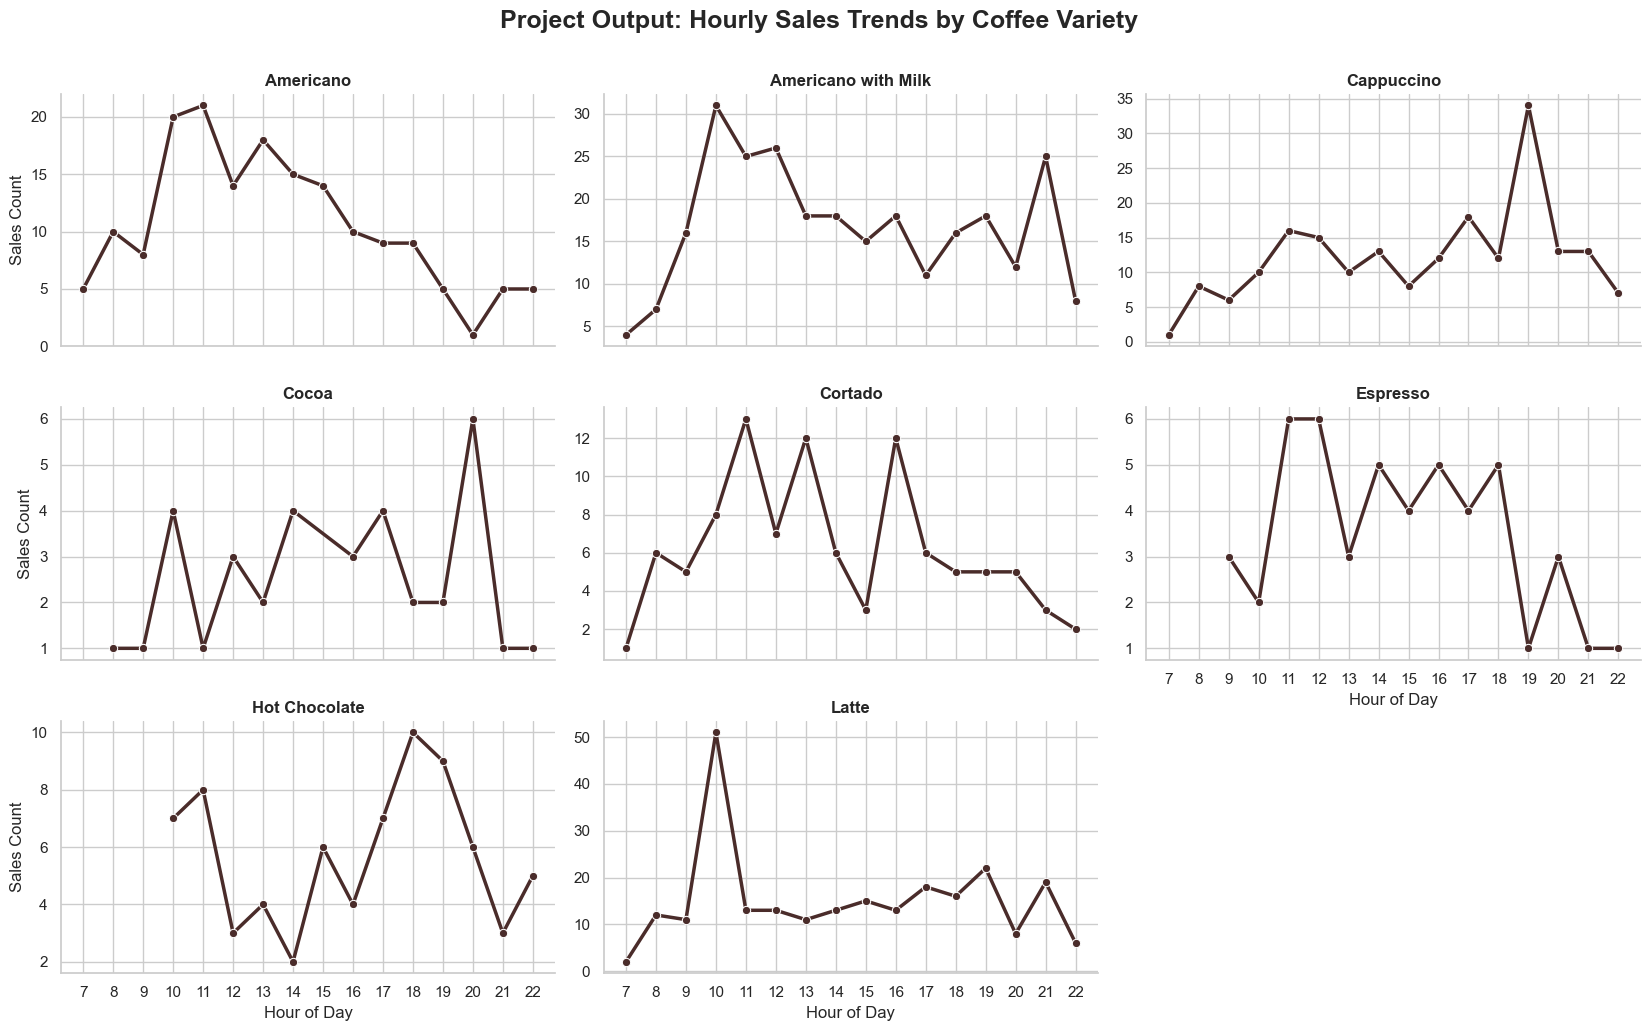

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare data: Group by coffee name and hour, then count the number of transactions
coffee_trends = df_clean.groupby(['coffee_name', 'hour']).size().reset_index(name='transaction_count')

# 2. Set professional aesthetics
sns.set_style("whitegrid")

# 3. Create the FacetGrid (3 columns per row)
g = sns.FacetGrid(coffee_trends, col="coffee_name", col_wrap=3, height=3.5, aspect=1.6, sharey=False)

# 4. Map the lineplot to each grid square
# Using a specific color and markers to match the reference document style
g.map(sns.lineplot, "hour", "transaction_count", marker="o", color="#4a2c2a", linewidth=2.5)

# 5. Clean up titles and labels
g.set_axis_labels("Hour of Day", "Sales Count")
g.set_titles(col_template="{col_name}", fontweight='bold', size=12)
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Project Output: Hourly Sales Trends by Coffee Variety', fontsize=18, fontweight='bold')

# Ensure x-axis shows all relevant hours (from 7 AM to 10 PM)
for ax in g.axes.flat:
    ax.set_xticks(range(7, 23))

plt.show()